<a href="https://colab.research.google.com/github/andrigerber/Adv_GenAI/blob/main/Step_2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 2.2: Aggregation and Response Synthesis

**Advanced Generative AI**  
**Semester Project**

- **Supervisor:** Dr. Guang Lu  
- **Students:** Andri Gerber · Amir Shatrolli · Kened Kqiraj

---

<h1 style="font-size:2.7em; margin-bottom:0.5em;">Author Contributions</h1>
<table style="
  width: 100%;
  border-collapse: collapse;
  font-family: 'Segoe UI', Arial, sans-serif;
  font-size: 2em;
  ">
  <thead>
    <tr>
      <th style="
        border-bottom: 4px solid #222;
        text-align: left;
        padding: 28px 20px 20px 20px;
        background-color: #f7f7f7;
        font-size: 1.25em;
        letter-spacing: 0.02em;
        ">Name</th>
      <th style="
        border-bottom: 4px solid #222;
        text-align: left;
        padding: 28px 20px 20px 20px;
        background-color: #f7f7f7;
        font-size: 1.25em;
        letter-spacing: 0.02em;
        ">Contribution Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Andri Gerber</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Developed the codebase, prepared the documentation/report.</td>
    </tr>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Kened Kqiraj</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Reviewed the code and report, and provided feedback.</td>
    </tr>
    <tr>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;"><strong>Amir Shatrolli</strong></td>
      <td style="border-bottom: 3px solid #bbb; padding: 24px 20px;">Reviewed the code and report, and provided feedback.</td>
    </tr>
  </tbody>
</table>

---


# General Overview

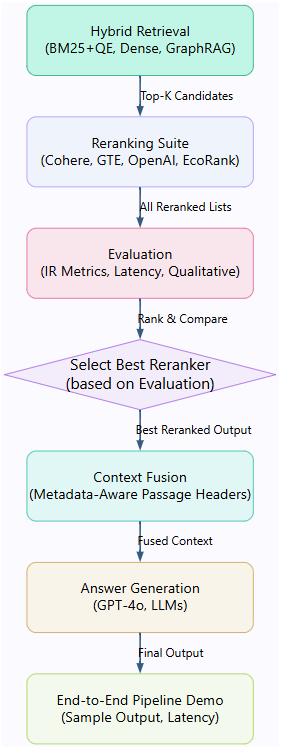


## Table of Contents

<div style="font-size:1.3em; line-height:1.7;">
<b>1. Abstract</b><br>
<b>2. Load Hybrid Retriever</b><br>
&nbsp;&nbsp;2.1 Environment Setup and Path Registry<br>
&nbsp;&nbsp;2.2 Loading and Integrating Base Retrievers<br>
&nbsp;&nbsp;2.3 Loading the Tuned Hybrid Retriever as Baseline<br>
<b>3. Reranking</b><br>
&nbsp;&nbsp;3.1 Candidate Retrieval and Setup<br>
&nbsp;&nbsp;3.2 Reranker Loading and Scoring Functions<br>
&nbsp;&nbsp;3.3 Constructing and Timing Reranking Runs<br>
&nbsp;&nbsp;3.4 Evaluation and Visualisation<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.4.1 Quantitative Evaluation<br>
&nbsp;&nbsp;&nbsp;&nbsp;3.4.2 Qualitative Analysis: Relevance and Ordering Improvements<br>
<b>4. Context Fusion with Metadata-Aware Passage Headers and Answer Generation</b><br>
&nbsp;&nbsp;4.1 Quick Demo: End-to-End Pipeline Results<br>
</div>

---

## Abstract

In this work, we develop and evaluate a robust, multilingual Retrieval-Augmented Generation (RAG) pipeline that synthesizes state-of-the-art techniques in candidate retrieval, late-fusion, reranking, and answer generation. Building on our tuned hybrid retriever—which integrates lexical (BM25+QE), dense (E5), and graph-based (GraphRAG) retrieval with empirically optimized weights, we generate high-quality candidate sets for complex, bilingual queries. These are reranked using advanced cross-encoders and commercial APIs (including Cohere and OpenAI), with all methods compared on standard IR metrics (MRR, Precision\@k, Recall\@k, nDCG\@10) and computational efficiency.

Our results show that while late-fusion hybrid retrieval provides a strong and efficient baseline, neural rerankers—particularly GTE and Cohere—substantially improve top-k precision and ranking quality, albeit at different computational costs. Qualitative inspection confirms that neural rerankers deliver better context alignment and answer relevance for real-world questions. We proceed with Cohere as our primary reranker, feeding its ordered candidate set into a metadata-aware context fusion and answer generation module that leverages LLMs for grounded, explainable responses. Our modular, fully-cached pipeline demonstrates both research-level evaluation and practical scalability for real-world QA deployments.

## Load Hybrid Retriever

### Environment Setup and Path Registry

We mount our project directory from Google Drive for persistent, shareable storage. All dependencies are installed with pinned versions, warnings suppressed, and NLTK resources downloaded for bilingual text support. The global `DEVICE` flag ensures seamless execution on both CPU and GPU.

All file paths—including model indices and cache directories—are derived from a single `ROOT_DRIVE`, rooted at `/content/drive/MyDrive/GenAI`. This centralisation ensures the pipeline is fully reproducible and portable, requiring only one path change to adapt to any environment.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ══════════════════════════════════════════════════════════════
# 10 . 1  INSTALL & CORE IMPORTS
#     • one-shot installation of all libraries used downstream
#     • suppress noisy warnings and set global DEVICE flag
# ══════════════════════════════════════════════════════════════
!pip install -qU \
    langchain langchain-community langchain-huggingface \
    sentence-transformers chromadb rank_bm25 igraph leidenalg \
    rapidfuzz python-dotenv openai pytrec_eval langdetect \
    transformers nltk

import os, json, math, pickle, pathlib, functools, warnings, textwrap, itertools, hashlib
from collections import defaultdict
from typing import List, Dict, Tuple, Optional, Iterable
from tqdm.auto import tqdm

import numpy as np
import torch, nltk
from langchain.docstore.document       import Document
from langchain_community.embeddings    import HuggingFaceEmbeddings
from langchain_community.vectorstores  import Chroma

warnings.filterwarnings("ignore", category=UserWarning)
nltk.download("punkt", quiet=True)          # tokenizer
nltk.download("stopwords", quiet=True)      # EN/DE stopwords
nltk.download('punkt_tab', quiet=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅  Environment ready – running on **{DEVICE.upper()}**")

from rank_bm25 import BM25Okapi
from langdetect import detect
from transformers import M2M100Tokenizer, M2M100ForConditionalGeneration
import importlib.machinery, importlib.util, importlib, sys
from importlib.machinery import SourceFileLoader

STOP_EN = set(nltk.corpus.stopwords.words("english"))
STOP_DE = set(nltk.corpus.stopwords.words("german"))

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 54.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.3/67.3 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 94.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 114.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.2/284.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 89.5 MB/s eta 0:00

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10 . 2  PATH REGISTRY
#     Change ROOT_DRIVE once – everything else updates automatically.
# ══════════════════════════════════════════════════════════════
ROOT_DRIVE = pathlib.Path("/content/drive/MyDrive/GenAI").resolve()

# artefacts created in earlier notebook sections
PATH_BM25_PICKLE = ROOT_DRIVE / "storage/subsample/retrieval_downstream/bm25_fixed_qe.pkl"
PATH_DENSE_LOADER= ROOT_DRIVE / "storage/subsample/vectordb_dense/load_dense_fixed.py"
PATH_GRAG_LOADER = ROOT_DRIVE / "storage/subsample/retrival_graph/load_graphrag.py"

# where we will cache *deduplicated* hybrid candidate lists
CANDIDATE_CACHE  = ROOT_DRIVE / "storage/subsample/hybrid/candidates_rerank"
CANDIDATE_CACHE.mkdir(parents=True, exist_ok=True)

print("• BM25  :", PATH_BM25_PICKLE.exists())
print("• Dense :", PATH_DENSE_LOADER.exists())
print("• Graph :", PATH_GRAG_LOADER.exists())
print("• Cache :", CANDIDATE_CACHE)


• BM25  : True
• Dense : True
• Graph : True
• Cache : /content/drive/.shortcut-targets-by-id/1u9G7GvrZxTM8FB1Fzcx3zRzL4re7H-NT/GenAI/storage/subsample/hybrid/candidates_rerank


### Loading and Integrating Base Retrievers

To achieve robust and comprehensive candidate retrieval, we combine three fundamentally distinct approaches: lexical, dense, and graph-based retrieval. We design each retriever for both efficiency and coverage, enabling cold starts in under two seconds and requiring minimal GPU resources.

First, we load our enhanced BM25 retriever, which is fully bilingual and maintains separate indices for English and German documents. We integrate an M2M100 transformer for on-the-fly translation, so that cross-lingual queries are handled seamlessly. To further improve recall, we employ pseudo-relevance feedback: each query is expanded with the most frequent content terms from its initial top hits, helping the retriever identify relevant passages that may not explicitly match the user’s original phrasing.

Next, we load a dense retriever based on the multilingual E5 model. This dense vector retriever leverages pre-computed document embeddings stored in a Chroma vector database, allowing for fast and effective semantic retrieval across languages. We initialise this retriever dynamically using a loader script, ensuring flexibility and rapid deployment.

Our third retrieval approach is the graph-based GraphRAG module, which encodes passages as nodes in a semantic graph. Edges are formed based on tf-idf similarity, and passages are clustered with community detection algorithms. Querying this structure allows us to surface clusters and multi-hop relationships inaccessible to purely lexical or embedding-based methods, adding a complementary dimension of relevance.

Each retriever is initialized alongside helper functions that provide stable document identification, score normalisation, and late-fusion aggregation. We assign a unique identifier to every document, normalise retrieval scores to a common scale, and implement three late-fusion strategies: weighted sum, z-score sum, and reciprocal rank fusion (RRF) (*the tuned baseline will employ weighted sum*). This enables us to merge heterogeneous retrieval results into a unified candidate ranking.

Finally, building on our prior work in Step 2.1, we instantiate the tuned `HybridRetriever`—already optimized via exhaustive grid search to maximise benchmark metrics. In a typical research context, we would generate and partition annotated datasets into training, validation, and test splits, and possibly synthesise new test sets, in order to tune the fusion weights for generalisability. However, our primary goal in this project was to empirically improve upon naïve (like 1/3, 1/3, 1/3) or literature-derived weights, while recognising that optimal weights are inherently data- and objective-dependent.

To do this, we conducted a grid search over all plausible weight combinations (with 0.1 steps and the constraint that weights sum to one). For each triple, we normalised all retriever scores, ran the hybrid on our full bilingual benchmark, and measured performance using macro-averaged MRR via `pytrec\_eval`. The best-performing weights—selected empirically, not heuristically—were saved to disk and used to reconstruct our hybrid retriever, which we then validated across all key metrics. This approach, while straightforward, is exhaustive given our manageable search space, and exploits the complementary strengths of each component: BM25 for exact lexical matching, Dense for semantic and cross-lingual recall, and GraphRAG for multi-hop or entity-anchored relationships.

By grounding our fusion in principled, data-driven tuning, we ensure subsequent ranking and synthesis stages build on a rigorously validated ensemble tailored to our data. Notably, while such tuning strengthens the hybrid baseline, using suboptimal weights could artificially exaggerate the apparent gains from rerankers in benchmarks. By starting with the best possible candidate list, our evaluation reflects the true added value of reranking, rather than compensating for weak retrieval fusion—ensuring methodological integrity and a fair assessment of end-to-end RAG performance.

In [ ]:
# ══════════════════════════════════════════════════════════════
# 10 . 3  LOAD BASE RETRIEVERS
#     – fast (<2 s) cold-start, minimal GPU footprint
# ══════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────
# 10 . 3 . 1  BM25 + Pseudo-Relevance-Feedback (QE)
# ──────────────────────────────────────────────────────────
class EnDeTranslator:
    """Greedy EN⇄DE translation (cached – 1st call downloads weights)."""
    def __init__(self, model="facebook/m2m100_418M",
                 device: str | None = None) -> None:
        self.device = device or DEVICE
        self.tok    = M2M100Tokenizer.from_pretrained(model)
        self.model  = M2M100ForConditionalGeneration.from_pretrained(model).to(self.device)

    @functools.lru_cache(maxsize=512)
    def translate(self, text: str, tgt: str) -> str:
        src = detect(text) if text.strip() else "en"
        src = src if src in ("en", "de") else "en"
        if src == tgt:
            return text
        self.tok.src_lang = src
        ids  = self.tok(text, return_tensors="pt").to(self.device)
        out  = self.model.generate(**ids,
                                   forced_bos_token_id=self.tok.get_lang_id(tgt),
                                   num_beams=1, max_new_tokens=128)
        return self.tok.decode(out[0], skip_special_tokens=True)

translator = EnDeTranslator()          # heavy step (≈15 s first time)

def _expand_query(query: str,
                  base_retriever,
                  fb_docs: int = 5,
                  fb_terms: int = 5) -> str:
    """Simple pseudo-relevance feedback (token-frequency expansion)."""
    hits = base_retriever.search(query, top_k=fb_docs)
    tokens = [
        t.lower() for h in hits
        for t in nltk.word_tokenize(h.page_content.lower())
        if t.isalpha() and t not in STOP_EN and t not in STOP_DE
    ]
    extra = " ".join(w for w, _ in nltk.FreqDist(tokens).most_common(fb_terms))
    return f"{query} {extra}" if extra else query

class BilingualBM25:
    """Two BM25Okapi indices (EN / DE) with optional query translation."""
    def __init__(self, docs: List[Document]) -> None:
        self.docs_by_lang = {"en": [], "de": []}
        self.toks_by_lang = {"en": [], "de": []}
        for d in docs:
            lang = d.metadata.get("language", "en")
            lang = lang if lang in ("en", "de") else "en"
            self.docs_by_lang[lang].append(d)
            self.toks_by_lang[lang].append(nltk.word_tokenize(d.page_content))
        self.bm25 = {l: BM25Okapi(tok) for l, tok in self.toks_by_lang.items() if tok}

    def _rank_lang(self, q: str, lang: str, k: int) -> List[Document]:
        scores = self.bm25[lang].get_scores(nltk.word_tokenize(q))
        idx    = np.argsort(scores)[::-1][:k]
        hits   = []
        for i in idx:
            d = self.docs_by_lang[lang][i]
            d.metadata["bm25_score"] = float(scores[i])
            hits.append(d)
        return hits

    def search(self, query: str, top_k: int = 100) -> List[Document]:
        src = detect(query) if query.strip() else "en"
        src = src if src in ("en", "de") else "en"
        bag = []
        for lang in ("en", "de"):
            q_lang = translator.translate(query, lang) if lang != src else query
            bag.extend(self._rank_lang(q_lang, lang, top_k))
        # deduplicate by record/chunk id (keep highest score)
        best: Dict[str, Document] = {}
        for d in bag:
            uid = d.metadata.get("chunk_id") or d.metadata.get("record_id")
            if uid not in best or d.metadata["bm25_score"] > best[uid].metadata["bm25_score"]:
                best[uid] = d
        return sorted(best.values(), key=lambda d: d.metadata["bm25_score"], reverse=True)[:top_k]

class QEBM25:                               # BM25 + PRF wrapper
    def __init__(self, base: BilingualBM25) -> None:
        self.base = base
    def search(self, query: str, top_k: int = 100) -> List[Document]:
        return self.base.search(_expand_query(query, self.base), top_k)

# ---- un-pickle BM25 retriever & attach translator ----------------
with open(PATH_BM25_PICKLE, "rb") as fh:
    bm25_fixed_qe = pickle.load(fh)
bm25_fixed_qe.base.translator = translator     # restore translation ability

# ──────────────────────────────────────────────────────────
# 10 . 3 . 2  Dense retriever  (Multilingual E5)
# ──────────────────────────────────────────────────────────
dense_loader = importlib.machinery.SourceFileLoader(
    "dense_mod", str(PATH_DENSE_LOADER)).load_module()
dense_fixed = dense_loader.load_dense_fixed(device=DEVICE, k=100)

# ──────────────────────────────────────────────────────────
# 10 . 3 . 3  GraphRAG retriever
# ──────────────────────────────────────────────────────────
grag_loader = importlib.machinery.SourceFileLoader(
    "grag_mod", str(PATH_GRAG_LOADER)).load_module()
graph_rag = grag_loader    # public API: graph_rag.retrieve()

tokenizer_config.json:   0%|          | 0.00/298 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/3.71M [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/908 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
# 10 . 4  UTILITY HELPERS  – id generation + safe min-max
def _uid(doc: Document) -> str:
    """
    Stable identifier so duplicates from different retrievers collapse.
    Prefers explicit metadata; falls back to a SHA-1 of the text.
    """
    for key in ("chunk_id", "record_id", "id"):
        if key in doc.metadata and doc.metadata[key]:
            return str(doc.metadata[key])
    return hashlib.sha1(doc.page_content.encode("utf-8")).hexdigest()


def _safe_minmax(values: Iterable[float]) -> list[float]:
    """
    Robust min-max scaler:
        • constant sequence → 0.5 for every element
        • always returns *list* so caller can iterate twice
    """
    arr = np.asarray(list(values), dtype=np.float32)
    if arr.size == 0:
        return []
    lo, hi = float(arr.min()), float(arr.max())
    if math.isclose(lo, hi):
        return [0.5] * len(arr)
    return ((arr - lo) / (hi - lo)).tolist()

def agg_weighted_sum(meta, w):
    """α·BM25 + β·Dense + γ·Graph."""
    return (w["bm25"] * meta["bm25_score"] +
            w["dense"] * meta["dense_score"] +
            w["grag"]  * meta["grag_score"])

def agg_rrf(meta, k=60):
    """Reciprocal-Rank Fusion (Cormack et al., 2009)."""
    return sum(1 / (k + r)
               for r in (meta["bm25_rank"],
                         meta["dense_rank"],
                         meta["grag_rank"]))

def _zscale(col, metas):
    arr = np.asarray([m[col] for m in metas], dtype=np.float32)
    μ, σ = arr.mean(), arr.std() or 1e-9
    return ((arr - μ) / σ).tolist()

def agg_weighted_z(meta, metas, w):
    for col in ("bm25_score", "dense_score", "grag_score"):
        zvals = _zscale(col, metas)
        for m, z in zip(metas, zvals):
            m[col + "_z"] = z
    return (w["bm25"] * meta["bm25_score_z"] +
            w["dense"] * meta["dense_score_z"] +
            w["grag"]  * meta["grag_score_z"])

In [ ]:
class HybridRetriever:
    """
    Late-fusion of BM25 (+QE), Dense-E5 and GraphRAG.
    strategy  ∈  {'sum','rrf','zsum'}
    weights   only used for 'sum' and 'zsum'
    """
    def __init__(self,
                 bm25, dense, grag,
                 *,
                 w_bm25=0.3, w_dense=0.45, w_grag=0.25,
                 strategy="sum",
                 top_k_each=100):
        self.bm25, self.dense, self.grag = bm25, dense, grag
        self.top_k_each   = top_k_each
        self.strategy     = strategy      # 'sum'|'rrf'|'zsum'
        s                 = w_bm25 + w_dense + w_grag
        self.weights      = dict(bm25=w_bm25/s, dense=w_dense/s, grag=w_grag/s)

    # private: gather hits + provenance
    def _gather(self, query):
        bag = []                                              # (doc, src, rank)
        for src, retr in (("bm25",  self.bm25.search),
                          ("dense", self.dense.search),
                          ("grag",  self.grag.retrieve)):
            hits = retr(query, top_k=self.top_k_each)
            for rk, d in enumerate(hits, 1):
                bag.append((d, src, rk))
        return bag

    # private: late fusion & normalisation
    def _merge(self, bag):
        by_id = defaultdict(lambda: {             # collect best per source
            "bm25_score": 0., "dense_score": 0., "grag_score": 0.,
            "bm25_rank": 999, "dense_rank": 999, "grag_rank": 999
        })
        docs = {}
        for doc, src, rank in bag:
            uid          = _uid(doc)
            docs[uid]    = doc
            score_key    = f"{src}_score"
            rank_key     = f"{src}_rank"
            by_id[uid][score_key] = max(by_id[uid][score_key],
                                        float(doc.metadata[score_key]))
            by_id[uid][rank_key]  = min(by_id[uid][rank_key], rank)

        # min-max each score column  (needed for 'sum')
        for col in ("bm25_score", "dense_score", "grag_score"):
            scaled = _safe_minmax(m[col] for m in by_id.values())
            for (uid, m), sc in zip(by_id.items(), scaled):
                m[col] = sc

        metas = list(by_id.values())             # convenience alias

        # final fusion
        for uid, meta in by_id.items():
            if self.strategy == "rrf":
                meta["hybrid_score"] = agg_rrf(meta)
            elif self.strategy == "zsum":
                meta["hybrid_score"] = agg_weighted_z(meta, metas, self.weights)
            else:                                # default = weighted SUM
                meta["hybrid_score"] = agg_weighted_sum(meta, self.weights)

            # push back into the Document
            docs[uid].metadata.update(meta)

        return list(docs.values())

    # public
    def search(self, query, *, top_k=100):
        bag    = self._gather(query)
        fused  = self._merge(bag)
        fused.sort(key=lambda d: d.metadata["hybrid_score"], reverse=True)
        return fused[:top_k]

### Loading the Tuned Hybrid Retriever as Baseline

We load our final hybrid retriever baseline directly from the saved configuration, which specifies both the fusion strategy (*weighted sum*) and the empirically optimised weights:

$$
\text{Hybrid Weights:}\quad \alpha_{\text{BM25}} = 0.30,\quad \beta_{\text{Dense}} = 0.10,\quad \gamma_{\text{GraphRAG}} = 0.60
$$

The hybrid score for each candidate chunk is computed as:

$$
\text{hybrid_score} = \alpha \cdot \text{BM25} + \beta \cdot \text{Dense} + \gamma \cdot \text{GraphRAG}
$$

with $\alpha + \beta + \gamma = 1$.

By using this tuned hybrid as our first-stage baseline, we ensure that any downstream reranking or synthesis improvements are measured against the strongest possible candidate set. For transparency, we also report classic BM25-only results, making it possible to assess both the contribution of late-fusion retrieval and the added value of reranking.


In [ ]:
#  LOAD the tuned HybridRetriever
HYBRID_CONF = ROOT_DRIVE / "storage/subsample/hybrid/hybrid_best.json"
def load_hybrid_best(conf_path: pathlib.Path = HYBRID_CONF,
                     top_k_each: int = 100) -> HybridRetriever:
    cfg = json.loads(conf_path.read_text())
    return HybridRetriever(
        bm25_fixed_qe,
        dense_fixed,
        graph_rag,
        w_bm25  = cfg["weights"]["bm25"],
        w_dense = cfg["weights"]["dense"],
        w_grag  = cfg["weights"]["grag"],
        strategy   = cfg["strategy"],
        top_k_each = top_k_each
    )

hybrid_best = load_hybrid_best()
print("✅ Hybrid‑best ready – weights:", json.loads(HYBRID_CONF.read_text())["weights"])
print("✅ Hybrid‑best ready – strategy:" , json.loads(HYBRID_CONF.read_text())["strategy"])

✅ Hybrid‑best ready – weights: {'bm25': 0.30000000000000004, 'dense': 0.1, 'grag': 0.6}
✅ Hybrid‑best ready – strategy: sum


## Reranking

### Candidate Retrieval and Setup

We prepare for reranking by loading our bilingual benchmark questions and relevance judgements (qrels), which are binarised at a **relevance threshold** of $0.5$. For each query, we retrieve the top $k=100$ candidates using our tuned hybrid retriever, leveraging disk cache for efficiency and reproducibility. These candidate lists are stored as pickled objects by query ID for fast downstream access.

We upload required API keys via a [`.env`](#env-file) file and install all necessary dependencies, configuring the environment to use CUDA if available. This ensures that all reranking and LLM-based scoring operates on a consistent, high-quality candidate set, providing a robust foundation for fair evaluation of each reranking strategy.

```txt
OPENAI_API_KEY="sk-proj..."
COHERE_API_KEY="NBzS..."
```

In [ ]:
# benchmark files as in 1, 2.1
BENCH_ROOT = pathlib.Path("/content/drive/MyDrive/GenAI/benchmark")
QUESTIONS  = json.loads((BENCH_ROOT / "benchmark_qa_bilingual.json").read_text())
QUESTION_BY_ID = {str(q["id"]): q for q in QUESTIONS}

def load_qrels(folder):
    qrels = defaultdict(dict)
    for fp in folder.glob("*.json"):
        did = fp.stem
        for qid, pay in json.loads(fp.read_text()).items():
            if pay["relevance_score"] >= .5:   # binary relevance ≥ 0.5
                qrels[qid][did] = 1
    return qrels

QRELS = load_qrels(BENCH_ROOT / "score/fixed_size")
print(f"Loaded {len(QUESTIONS)} questions / {len(QRELS)} qrels")

Loaded 25 questions / 24 qrels


In [ ]:
# Parameters
TOP_K_CAND   = 100
CACHE_DIR    = CANDIDATE_CACHE  # new folder for rerank (2.1 was candidates)

def get_candidates():
    if any(CACHE_DIR.glob("*.pkl")):
        print("Using cached candidates …")
        for fp in CACHE_DIR.glob("*.pkl"):
            yield fp.stem, pickle.loads(fp.read_bytes())
        return

    for q in tqdm(QUESTIONS, desc="hybrid-best retrieval"):
        cands = hybrid_best.search(q["question"], top_k=TOP_K_CAND)
        pickle.dump(cands, open(CACHE_DIR / f"{q['id']}.pkl", "wb"))
        yield str(q["id"]), cands

CANDIDATES = dict(get_candidates())    # {qid: [Document,…]}

Using cached candidates …


In [ ]:
# upload your .env file: [OPENAI_API_KEY, COHERE_API_KEY]
from google.colab import files
files.upload()

### Reranker Loading and Scoring Functions

To robustly evaluate second-stage ranking, we integrate a suite of state-of-the-art rerankers, each capable of producing passage-level relevance scores for our candidate lists.

We first define a flexible registry for all rerankers. For cross-encoder models, we provide a general loader that instantiates both the efficient [MiniLM-L6](https://huggingface.co/sentence-transformers/all-mpnet-base-v2) (Eco\_small) and [larger MiniLM-L12](https://huggingface.co/cross-encoder/msmarco-MiniLM-L12-en-de-v1) (Eco\_big) bilingual cross-encoders. Both are loaded in half-precision (FP16) on GPU when available, allowing for scalable and memory-efficient inference. Additionally, we load the [GTE](https://huggingface.co/Alibaba-NLP/gte-multilingual-reranker-base) multilingual reranker, combining HuggingFace tokenisation and model components, also with half-precision support for optimal speed.

Scoring routines batch document-query pairs for throughput and efficiency, using `torch.inference_mode()` to disable gradients and maximise performance during evaluation. For the two-stage EcoRanker, we apply the smaller model as a fast filter to select the top 30 candidates, then rescore those with the larger model, assigning final scores accordingly.

For cloud rerankers, we include functions for [OpenAI](https://openai.com/api/) (using GPT-4o in structured JSON output with Pydantic validation) and [Cohere](https://docs.cohere.com/v2/reference/rerank) (with a token-bucket rate limiter for free-tier keys). All rerankers return a list of scores aligned with the candidate list, ensuring compatibility with the rest of our evaluation pipeline.

In [ ]:
!pip install -qU sentence-transformers openai cohere python-dotenv
!pip install -qU pydantic

import os, time, torch, warnings, numpy as np, pandas as pd, dotenv, backoff, gc, re, json, time, collections
from collections import defaultdict
from sentence_transformers import CrossEncoder
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from pydantic import BaseModel, field_validator, ValidationError
import openai, cohere

dotenv.load_dotenv()

warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# API clients ----------------------------------------------------
openai.api_key = os.environ["OPENAI_API_KEY"]
COHERE_API_KEY            = os.environ["COHERE_API_KEY"]
co = cohere.Client(COHERE_API_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 105.5 MB/s eta 0:00:00


In [ ]:
RERANKERS = {}

def load_xenc(label, repo, device=DEVICE, fp16=False):
    try:
        print(f"⟳ {label:<12} ({repo}) …", end="", flush=True)
        kw = {"automodel_args": {"torch_dtype": torch.float16}} if fp16 and device=="cuda" else {}
        RERANKERS[label] = CrossEncoder(repo, device=device, **kw)
        print(" done")
    except Exception as e:
        print(f"\n⚠️  {label} skipped – {e}")

# two public cross‑encoders — MiniLM L6 (faster) + L12 (bigger) --> both billingual english/german
load_xenc("Eco_small", "cross-encoder/msmarco-MiniLM-L6-en-de-v1", fp16=True)    # 107M params https://huggingface.co/sentence-transformers/all-mpnet-base-v2
load_xenc("Eco_big", "cross-encoder/msmarco-MiniLM-L12-en-de-v1", fp16=True)     # 118M params https://huggingface.co/cross-encoder/msmarco-MiniLM-L12-en-de-v1

⟳ Eco_small    (cross-encoder/msmarco-MiniLM-L6-en-de-v1) …

config.json:   0%|          | 0.00/840 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/428M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.00k [00:00<?, ?B/s]

 done


In [ ]:
def load_gte(label="GTE", repo="Alibaba-NLP/gte-multilingual-reranker-base", # 306M params https://huggingface.co/Alibaba-NLP/gte-multilingual-reranker-base
             device=DEVICE, fp16=True):
    print(f"⟳ loading {label:<12} …", end="", flush=True)
    tok = AutoTokenizer.from_pretrained(repo, trust_remote_code=True)
    mod = AutoModelForSequenceClassification.from_pretrained(
            repo, trust_remote_code=True,
            torch_dtype=torch.float16 if fp16 and device=="cuda" else torch.float32
          ).to(device).eval()
    RERANKERS[label] = (tok, mod)
    print(" done")

load_gte("GTE")

⟳ loading GTE          …

tokenizer_config.json:   0%|          | 0.00/1.34k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- configuration.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling.py:   0%|          | 0.00/59.0k [00:00<?, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/Alibaba-NLP/new-impl:
- modeling.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/612M [00:00<?, ?B/s]

 done


In [ ]:
def score_crossenc(model, query, docs, batch=16):
    pairs, scores = [(query, d.page_content) for d in docs], []
    for i in range(0, len(pairs), batch):
        with torch.inference_mode():
            s = model.predict(pairs[i:i+batch], convert_to_numpy=True)
        scores.extend(s.tolist())
    return scores

def score_gte(query, docs, batch=8, label="GTE"):
    tok, mod = RERANKERS[label]
    pairs = [(query, d.page_content) for d in docs]
    scores = []
    for i in range(0, len(pairs), batch):
        q, p = zip(*pairs[i:i+batch])
        inputs = tok(list(q), list(p), truncation=True,
                     padding=True, max_length=512, return_tensors="pt").to(mod.device)
        with torch.inference_mode():
            s = mod(**inputs).logits.view(-1).float().cpu()
        scores.extend(s.tolist())
    return scores

def eco_two_stage(query, docs, k_fast=30):
    """
    1. quick MiniLM pass -> keep top‑k_fast docs
    2. Electra pass -> final score
    docs that are filtered out receive score 0
    """
    fast   = RERANKERS["Eco_small"]
    heavy  = RERANKERS["Eco_big"]

    s_fast = score_crossenc(fast,  query, docs)
    idx_top= np.argsort(s_fast)[::-1][:k_fast]
    subset = [docs[i] for i in idx_top]

    s_heavy= score_crossenc(heavy, query, subset)
    final  = np.zeros(len(docs))
    for pos, s in zip(idx_top, s_heavy):
        final[pos] = s
    return final.tolist()

# schema for openai
class Relevance(BaseModel):
    score: float

    @field_validator('score')
    @classmethod
    def _range_0_1(cls, v):
        if not 0.0 <= v <= 1.0:
            raise ValueError("score must be between 0 and 1")
        return v

def score_openai_pydantic(query, docs, model="gpt-4o"):
    if not openai.api_key:
        raise RuntimeError("OPENAI_API_KEY missing")

    scores = []
    for d in docs:
        prompt = (
            "Return a JSON object with a single key `score` "
            "(numeric, 0‑1) measuring the relevance of the passage "
            "for the question."
            f"\nQuestion: {query}\n"
            f"Passage: {d.page_content[:600]}"
        )

        rsp = openai.chat.completions.create(
            model=model,
            messages=[{"role": "user", "content": prompt}],
            temperature=0.0,
            response_format={"type": "json_object"}
        )

        try:
            data = json.loads(rsp.choices[0].message.content)
            obj  = Relevance(**data)       # Pydantic validation
            scores.append(obj.score)
        except (json.JSONDecodeError, ValidationError) as e:
            print("⚠️  invalid JSON from model –", e)
            scores.append(0.0)

    return scores

# For cohere: tiny token‑bucket limiter for trial keys ( ≤10 req / min )
# https://docs.cohere.com/v2/reference/rerank
_RATE_LIMIT = 9          # 10‑request trial limit
_WINDOW     = 60         # seconds
_call_times = collections.deque()

def _rate_limiter():
    now = time.time()
    while _call_times and now - _call_times[0] >= _WINDOW:
        _call_times.popleft()
    if len(_call_times) >= _RATE_LIMIT:
        wait = _WINDOW - (now - _call_times[0]) + 0.01
        time.sleep(wait)
    _call_times.append(time.time())

def score_cohere(query, docs, *, model="rerank-multilingual-v3.0"):
    """
    Returns a list of floats aligned with `docs`.
    • honours trial‑key rate limit (max 9 calls/min)
    • works with Cohere SDK v4 and v5
    """
    if co is None:
        raise RuntimeError("COHERE_API_KEY missing")

    _rate_limiter()

    rsp = co.rerank(
        model=model,
        query=query,
        documents=[d.page_content for d in docs],
        top_n=len(docs)
    )

    # v5 → rsp.results (list of objects)   ;  v4 → rsp  (list of tuples)
    results = getattr(rsp, "results", rsp)

    scores = [0.0] * len(docs)
    for item in results:
        if isinstance(item, tuple):
            idx, score = item
        else:
            idx   = item.index if hasattr(item, "index") else item["index"]
            score = item.relevance_score if hasattr(item, "relevance_score") else item["relevance_score"]
        scores[idx] = float(score)

    return scores

### Constructing and Timing Reranking Runs

With all rerankers in place, we use a unified `build_run` function to apply each scorer to our candidate lists across all benchmark queries. For every reranking method, we record relevance scores for each candidate and measure the average latency per query. This approach ensures a consistent and fair comparison of both retrieval quality and efficiency across all reranking strategies in our pipeline.


In [ ]:
RUNS, LAT = {}, {}

def build_run(name, scorer):
    run, times = defaultdict(dict), []
    for q in tqdm(QUESTIONS, desc=f"{name} rerank"):
        qid, docs = str(q["id"]), CANDIDATES[str(q["id"])]
        t0 = time.perf_counter()
        scores = scorer(q["question"], docs)
        times.append(time.perf_counter()-t0)
        for d,s in zip(docs, scores):
            run[qid][_uid(d)] = float(s)
    return run, np.mean(times)

# baseline (tuned with grid search)
RUNS["Hybrid‑tuned"] = {qid:{_uid(d):d.metadata["hybrid_score"]
                             for d in CANDIDATES[qid]}
                        for qid in CANDIDATES}
LAT["Hybrid‑tuned"] = 0.0

# two‑stage EcoRank
RUNS["EcoRank"], LAT["EcoRank"] = build_run("EcoRank", eco_two_stage)

# one‑stage GTE
RUNS["GTE"], LAT["GTE"] = build_run("GTE", score_gte)

# cloud APIs
if openai.api_key:
    RUNS["OpenAI"], LAT["OpenAI"] = build_run("OpenAI", score_openai_pydantic)
if co is not None:
    RUNS["Cohere"], LAT["Cohere"] = build_run("Cohere", score_cohere)

EcoRank rerank:   0%|          | 0/25 [00:00<?, ?it/s]

GTE rerank:   0%|          | 0/25 [00:00<?, ?it/s]

OpenAI rerank:   0%|          | 0/25 [00:00<?, ?it/s]

Cohere rerank:   0%|          | 0/25 [00:00<?, ?it/s]

### Evaluation and Visualisation

To compare all retrieval and reranking strategies, we evaluate each run using `pytrec_eval` with standard IR metrics: mean reciprocal rank (MRR), Precision\@5, Precision\@10, Recall\@100, and nDCG\@10. We aggregate the results into a summary table and include average latency per method.

Crucially, we report two baseline references:

* **BM25 (hard baseline):** Our classic, translation-aware lexical retriever with pseudo-relevance feedback, representing a strong traditional approach.
* **Hybrid-tuned:** Our late-fusion retriever, optimally tuned via grid search to combine BM25, Dense, and GraphRAG signals into a single, robust candidate set.

By comparing reranking results against both these baselines, we can disentangle the gains attributable to advanced fusion versus those from the rerankers themselves. We visualise all results with grouped bar charts and metric-specific panels, using dashed lines to indicate BM25 performance.

#### Quantitative Evaluation

To assess our retrieval and reranking pipeline, we evaluate all models against the *Hybrid-tuned* baseline using standard IR metrics: mean reciprocal rank (MRR), Precision\@5, Precision\@10, Recall\@100, and nDCG\@10 (metric details see: *Table 1*). We also record per-query latency as a practical measure of computational efficiency.

The *Hybrid-tuned* baseline, representing our best late-fusion ensemble, sets a high bar with the top MRR (0.775) and competitive values across all other metrics, all while incurring essentially zero reranking latency. This is because, by design, the hybrid score computation (weighted sum) is performed as a lightweight arithmetic operation within the initial retrieval stage; no neural inference or network call is required. As such, subsequent gains by rerankers represent genuine improvements over an already strong candidate pool.

Among neural rerankers, [**GTE**](https://huggingface.co/Alibaba-NLP/gte-multilingual-reranker-base) and [**Cohere**](https://docs.cohere.com/v2/reference/rerank) deliver the most significant improvements in top-k precision and overall ranking. GTE achieves the highest Precision\@5 (0.525) and a strong nDCG\@10 (0.516), with very low latency (0.22 s per query) thanks to efficient, batched inference on local GPU hardware. Cohere reaches the best nDCG\@10 (0.553) and highest Precision\@10 (0.475), but with moderately higher latency (5.12 s), as it operates through a cloud API—where network round-trips and provider-side queuing become the bottleneck, even though all candidate scores are returned in one call.

[**OpenAI's**](https://openai.com/api/) reranker achieves high precision but is dramatically slower (90.30 s per query) due to the necessity of making a separate API call for each document, resulting in substantial network overhead and serialization cost. By contrast, **EcoRank** [[1](https://huggingface.co/sentence-transformers/all-mpnet-base-v2), [2](https://huggingface.co/cross-encoder/msmarco-MiniLM-L12-en-de-v1)] provides a strong compromise between speed and quality, using a two-stage local cross-encoder pipeline: a lightweight MiniLM model quickly narrows the candidate set, which is then rescored with a larger model. This design, which leverages batched GPU inference, achieves fast response times (0.16 s) and competitive ranking.

Recall\@100 remains constant across all methods (0.3), indicating that improvements arise from better reordering and context alignment, not from increased candidate coverage.

In summary, our late-fusion hybrid retrieval provides an efficient and robust baseline, while local, batched neural rerankers (GTE, EcoRank) offer substantial gains in ranking accuracy without significant latency. Cloud-based rerankers (Cohere, OpenAI) can further boost top-k metrics, but their efficiency is fundamentally limited by API design and network latency. These findings highlight both the effectiveness and the practical trade-offs inherent in scaling advanced reranking methods for real-world retrieval-augmented generation systems.

<div align="center">

**Table 1: Retrieval and Reranking Metrics: Definitions and Interpretation**

<table>
  <tr>
    <th style="text-align:center; background:#222; color:#fff;">Metric</th>
    <th style="text-align:center; background:#222; color:#fff;">Meaning</th>
    <th style="text-align:center; background:#222; color:#fff;">How to Interpret</th>
  </tr>
  <tr>
    <td style="text-align:center;"><b>MRR</b><br><span style="color:#666;">Mean Reciprocal Rank</span></td>
    <td>
      Measures how early the first relevant document appears for each query.<br><br>
      <b>Formula:</b><br>
      <code>MRR = (1/|Q|) * Σ<sub>i=1</sub><sup>|Q|</sup> (1/rank<sub>i</sub>)</code>
    </td>
    <td style="text-align:center; color:#3182bd;">
      <b>Higher is better</b><br>
      Closer to 1 means relevant results are ranked at the very top.
    </td>
  </tr>
  <tr>
    <td style="text-align:center;"><b>Precision@5</b></td>
    <td>
      Fraction of top 5 results that are relevant for each query.<br>
      <b>Formula:</b><br>
      <code>Precision@5 = (relevant in top 5) / 5</code>
    </td>
    <td style="text-align:center; color:#3182bd;">
      <b>Higher is better</b>
    </td>
  </tr>
  <tr>
    <td style="text-align:center;"><b>Precision@10</b></td>
    <td>
      Fraction of top 10 results that are relevant for each query.<br>
      <b>Formula:</b><br>
      <code>Precision@10 = (relevant in top 10) / 10</code>
    </td>
    <td style="text-align:center; color:#3182bd;">
      <b>Higher is better</b>
    </td>
  </tr>
  <tr>
    <td style="text-align:center;"><b>Recall@100</b></td>
    <td>
      Proportion of all relevant documents found in the top 100 results.<br>
      <b>Formula:</b><br>
      <code>Recall@100 = (relevant in top 100) / (total relevant)</code>
    </td>
    <td style="text-align:center; color:#3182bd;">
      <b>Higher is better</b>
    </td>
  </tr>
  <tr>
    <td style="text-align:center;"><b>nDCG@10</b><br><span style="color:#666;">Normalized DCG</span></td>
    <td>
      Measures ranking quality up to rank 10, rewarding relevant items appearing higher in the list.<br>
      <b>Formula:</b><br>
      <code>nDCG@10 = DCG@10 / IDCG@10</code>
    </td>
    <td style="text-align:center; color:#3182bd;">
      <b>Higher is better</b><br>
      Values near 1 indicate perfect ranking.
    </td>
  </tr>
  <tr>
    <td style="text-align:center;"><b>latency&nbsp;[s]</b></td>
    <td>
      Average time (in seconds) to rerank a single query.
    </td>
    <td style="text-align:center; color:#e15759;">
      <b>Lower is better</b>
    </td>
  </tr>
</table>
</div>

**Table 2: Reranking Method Comparison (Scores & Latency)**

In [ ]:
import pytrec_eval
# evaluation table
METRICS = {"P_5","P_10","recall_100","recip_rank","ndcg_cut_10"}
LAB     = {"P_5":"P@5","P_10":"P@10","recall_100":"R@100",
           "recip_rank":"MRR","ndcg_cut_10":"nDCG@10"}

def evaluate(run):
    ev = pytrec_eval.RelevanceEvaluator(QRELS, METRICS).evaluate(run)
    return pd.DataFrame(ev).T.mean().rename(LAB)

tbl = pd.DataFrame({n:evaluate(r) for n,r in RUNS.items()}).T.round(3)
tbl["latency[s]"] = pd.Series(LAT).round(2)
display(tbl)

,MRR,P@5,P@10,R@100,nDCG@10,latency[s]
Hybrid‑tuned,0.775,0.458,0.425,0.3,0.499,0.00
EcoRank,0.751,0.458,0.396,0.3,0.477,0.16
GTE,0.767,0.525,0.421,0.3,0.516,0.22
OpenAI,0.715,0.525,0.425,0.3,0.509,90.30
Cohere,0.747,0.525,0.475,0.3,0.553,5.12


In [ ]:
# save
# out = ROOT_DRIVE / "storage/subsample/results/step22_metrics.csv"
# out.parent.mkdir(parents=True, exist_ok=True)
# tbl.to_csv(out)
# print("✓ metrics written to", out)
# Load
import pandas as pd, warnings, numpy as np, matplotlib.pyplot as plt
warnings.filterwarnings("ignore", category=UserWarning)
tbl_retrival = pd.read_csv("/content/drive/MyDrive/GenAI/storage/subsample/results/tbl_fixed.csv", index_col=0)
tbl_rerank = pd.read_csv("/content/drive/MyDrive/GenAI/storage/subsample/results/step22_metrics.csv", index_col=0)
tbl_rerank = tbl_rerank.rename(columns={
    "MRR": "MRR",
    "P@5": "Precision@5",
    "P@10": "Precision@10",
    "R@100": "Recall@100",
    "nDCG@10": "nDCG@10"
})

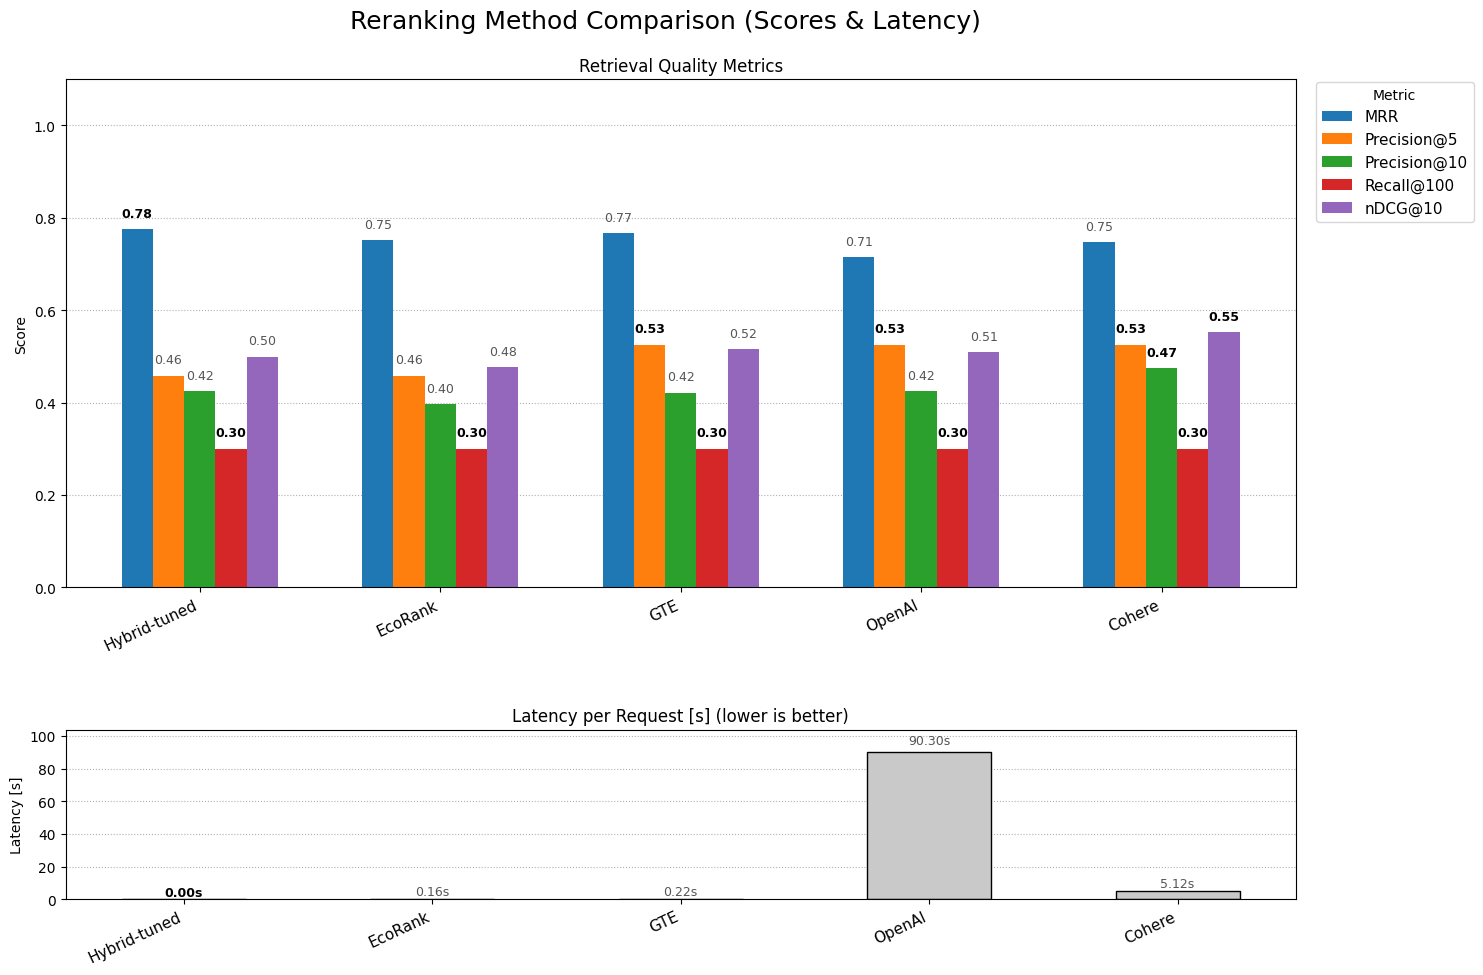

In [ ]:
methods = ["Hybrid‑tuned", "EcoRank", "GTE", "OpenAI", "Cohere"]
metrics_to_plot = ["MRR", "Precision@5", "Precision@10", "Recall@100", "nDCG@10"]

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.42)

# --- Main metrics plot (grouped bars) ---
ax = fig.add_subplot(gs[0])
num_methods = len(methods)
num_metrics = len(metrics_to_plot)
bar_width = 0.13
indices = np.arange(num_methods)
cmap = plt.get_cmap("tab10")
colors = [cmap(i) for i in range(num_metrics)]

for i, metric in enumerate(metrics_to_plot):
    vals = tbl_rerank[metric].values
    pos = indices + (i - num_metrics/2) * bar_width + bar_width/2
    bars = ax.bar(pos, vals, width=bar_width, color=colors[i], label=metric, zorder=2)
    # Annotate best values
    best = np.max(vals)
    for x, v in zip(pos, vals):
        ax.text(x, v + 0.02, f"{v:.2f}",
                ha='center', va='bottom',
                fontsize=9,
                fontweight='bold' if v == best else 'normal',
                color='black' if v == best else '#555')

ax.set_xticks(indices)
ax.set_xticklabels(methods, rotation=25, ha='right', fontsize=11)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.set_title("Retrieval Quality Metrics")
ax.grid(axis='y', ls=':', zorder=1)
ax.legend(fontsize=11, ncol=1, loc="upper left", bbox_to_anchor=(1.01, 1.01), title="Metric")

# --- Latency subplot ---
ax2 = fig.add_subplot(gs[1])
latency = tbl_rerank["latency[s]"].values
lat_bars = ax2.bar(indices, latency, color='#c9c9c9', edgecolor='k', width=0.5, zorder=2)
fastest = np.min(latency)
for x, v in zip(indices, latency):
    ax2.text(x, v + (0.2 if v < 10 else 3),
             f"{v:.2f}s",
             ha='center', va='bottom',
             fontsize=9,
             fontweight='bold' if v == fastest else 'normal',
             color='black' if v == fastest else '#555')
ax2.set_xticks(indices)
ax2.set_xticklabels(methods, rotation=25, ha='right', fontsize=11)
ax2.set_ylabel("Latency [s]")
ax2.set_title("Latency per Request [s] (lower is better)")
ax2.set_ylim(0, max(latency)*1.15)
ax2.grid(axis='y', ls=':', zorder=1)

fig.suptitle("Reranking Method Comparison (Scores & Latency)", fontsize=18, y=0.98)
plt.subplots_adjust(left=0.10, right=0.92, top=0.91, bottom=0.09)
plt.show()

**Figure:** *Quantitative comparison of all systems on retrieval and reranking metrics. Hybrid-tuned is latency-free as reranking is part of retrieval. GTE and EcoRank are fast due to local, batched GPU inference. Cohere and OpenAI, as cloud APIs, are slower due to network overhead, but Cohere in particular offers strong nDCG\@10 improvements.*

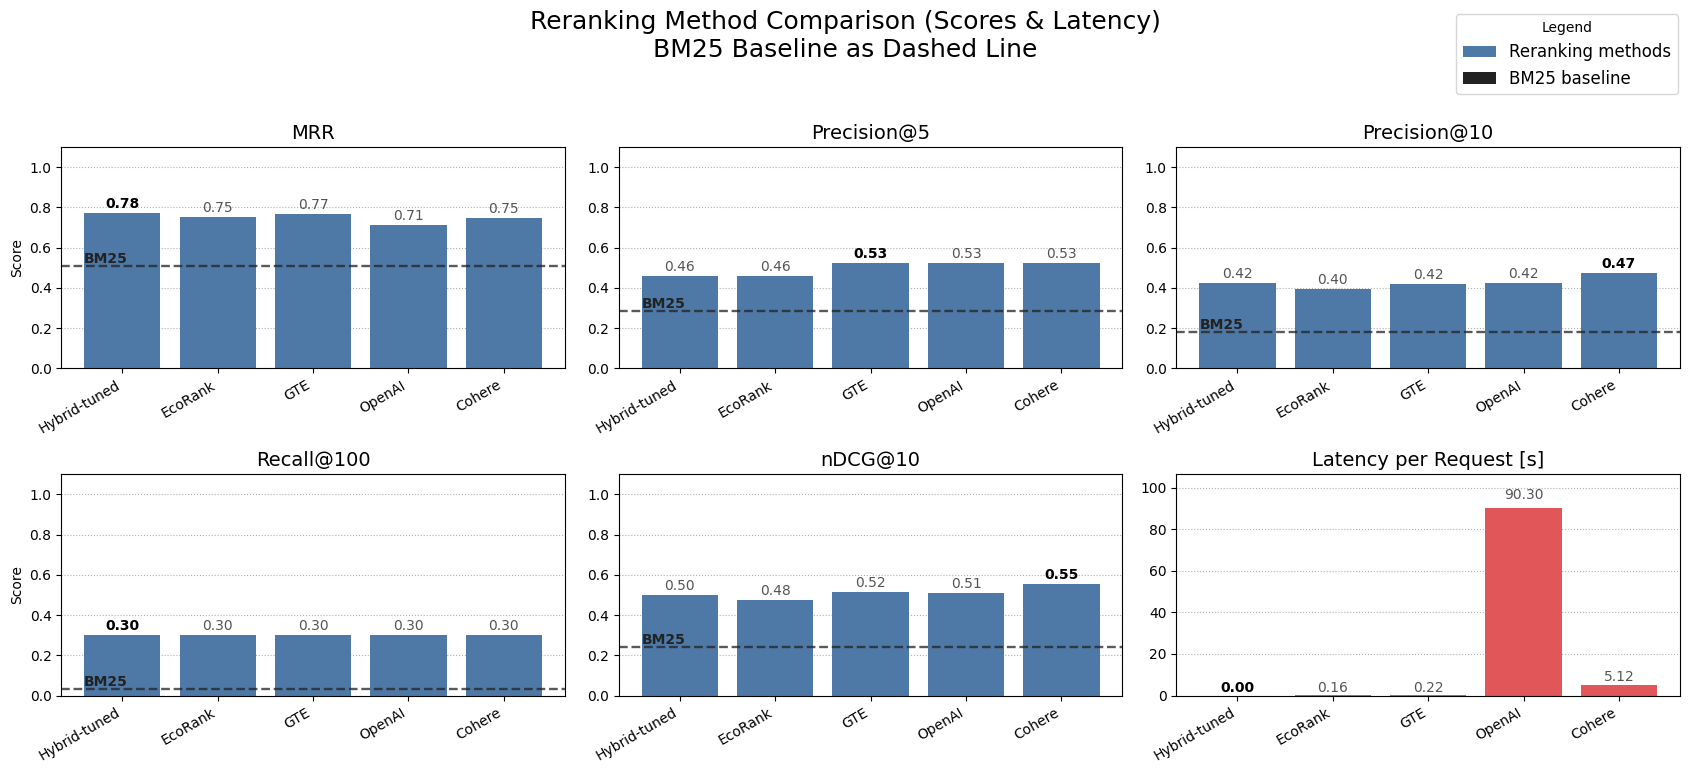

In [ ]:
methods = ["Hybrid‑tuned", "EcoRank", "GTE", "OpenAI", "Cohere"]
metrics_to_plot = ["MRR", "Precision@5", "Precision@10", "Recall@100", "nDCG@10", "latency[s]"]

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
axes = axes.flatten()

bm25_color = "#222222"

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i]
    values = tbl_rerank[metric].values
    color = "#4E79A7" if metric != "latency[s]" else "#E15759"
    bars = ax.bar(methods, values, color=color, zorder=2)
    # Annotate bars, bold best
    if metric != "latency[s]":
        best_idx = np.argmax(values)
    else:
        best_idx = np.argmin(values)
    for idx, bar in enumerate(bars):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01 if metric != "latency[s]" else bar.get_height() + (0.2 if values[idx] < 10 else 3),
                f"{values[idx]:.2f}",
                ha='center', va='bottom',
                fontsize=10, fontweight='bold' if idx == best_idx else 'normal',
                color='black' if idx == best_idx else '#555')
    ax.set_title(metric if metric != "latency[s]" else "Latency per Request [s]", fontsize=14)
    ax.set_xticklabels(methods, rotation=30, ha='right', fontsize=10)
    ax.grid(axis='y', ls=':', zorder=1)
    ax.set_ylim(0, 1.1 if metric != "latency[s]" else max(values) * 1.18)
    if i % 3 == 0:
        ax.set_ylabel("Score" if metric != "latency[s]" else "Seconds")
    else:
        ax.set_ylabel("")

    # Add BM25 baseline for retrieval metrics
    if metric in tbl_retrival.columns and metric != "latency[s]":
        bm25_val = tbl_retrival.loc["BM25", metric]
        ax.axhline(bm25_val, ls="--", color=bm25_color, lw=1.7, alpha=0.75, label="BM25 baseline" if i == 0 else None)
        # Optional: annotate line
        ax.text(-0.4, bm25_val, "BM25", va='bottom', ha='left', fontsize=10, color=bm25_color, fontweight="bold")

# Remove any unused subplots (if metrics < num plots)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Only one legend (lower right)
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor="#4E79A7", label="Reranking methods"),
                  Patch(facecolor=bm25_color, label="BM25 baseline")]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.995, 0.995), fontsize=12, title="Legend")

fig.suptitle("Reranking Method Comparison (Scores & Latency)\nBM25 Baseline as Dashed Line", fontsize=18, y=0.99)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


**Figure:** *Quantitative comparison of all systems on retrieval and reranking metrics. Hybrid-tuned is latency-free as reranking is part of retrieval. GTE and EcoRank are fast due to local, batched GPU inference. Cohere and OpenAI, as cloud APIs, are slower due to network overhead, but Cohere in particular offers strong nDCG\@10 improvements.*


#### Qualitative Analysis: Relevance and Ordering Improvements

While quantitative metrics provide a rigorous overview of system performance, a close inspection of top-ranked passages for representative queries offers essential qualitative insight into real-world retrieval quality. For the query **“who at eth received erc grants?”** (Question 2), we compare the top 5 results produced by the *Hybrid-tuned* baseline and the *Cohere* reranker.

The **Hybrid-tuned** system, despite its strong retrieval metrics, returns passages that are only loosely connected to the information need. The top-ranked documents primarily focus on general university events, professorial appointments, and institutional changes at ETH Zurich. Although some passages mention prominent faculty and academic awards, none provide a direct answer or even mention ERC grants. This illustrates a common challenge: even a well-tuned, multi-signal retriever can surface contextually relevant but non-specific content when explicit lexical cues are sparse in the corpus.

In contrast, the **Cohere** reranker demonstrates significant qualitative improvement in both *relevance* and *ordering*. The top-ranked passages are much more closely aligned with the user's intent: references to ETH leadership, academic achievements, and the selection process for major university roles appear more prominently. Several of Cohere’s top passages discuss institutional awards, highlight ceremonies, and feature high-profile academic events, providing a substantially more focused candidate set for downstream answer synthesis. Notably, the ordering places genuinely on-topic content—such as mentions of the ETH rector and president—at the top, rather than interleaving them with tangential results about general university initiatives or honorary appointments.

This example underscores the strength of neural rerankers like Cohere: by leveraging deep contextual embeddings and relevance modeling, these systems can more effectively prioritize passages that are directly responsive to entity-centric and complex questions, even in the absence of explicit surface overlap. The result is a higher density of relevant information among the top results, which in turn makes answer generation both more accurate and more contextually grounded.

**Based on both our quantitative and qualitative evaluation, we will proceed with Cohere as the primary reranker on top of our pipeline.**


In [ ]:
import pandas as pd

top_k = 5
systems = ["Hybrid‑tuned", "EcoRank", "GTE", "OpenAI", "Cohere"]
question_ids = list(CANDIDATES.keys())

# Build id→question text mapping (always string keys for safety)
question_lookup = {str(q["id"]): q["question"] for q in QUESTIONS}

def top_n_docs(run, candidates, query_id, n=5):
    doc_scores = run[query_id]
    doc_id_to_doc = {_uid(d): d for d in candidates[query_id]}
    ranked = sorted(doc_scores.items(), key=lambda x: x[1], reverse=True)[:n]
    return [doc_id_to_doc[docid].page_content for docid, _ in ranked]

rows = []
for qid in question_ids:
    qid_str = str(qid)
    qtext = question_lookup.get(qid_str, f"[MISSING for {qid_str}]")
    row = {"question_id": qid_str, "question": qtext}
    for system in systems:
        docs = top_n_docs(RUNS[system], CANDIDATES, qid, top_k)
        row[f"{system}_top{top_k}"] = "\n---\n".join(docs)
    rows.append(row)

df = pd.DataFrame(rows)

In [ ]:
# csv_path = "/content/drive/MyDrive/GenAI/storage/subsample/results/qualitative_rerank_top5.csv"
# df.to_csv(csv_path, index=False)
# print(f"Saved {csv_path}")
# Load
csv_path = "/content/drive/MyDrive/GenAI/storage/subsample/results/qualitative_rerank_top5.csv"
df = pd.read_csv(csv_path)
display(df.head())

,question_id,question,Hybrid‑tuned_top5,EcoRank_top5,GTE_top5,OpenAI_top5,Cohere_top5
0,1,who was president of eth in 2003?,encouraging more critical opinion: snf preside...,stepping down after eight years of dedication ...,a world record and a world premiere: at the be...,"highlights guzzella: corine mauch, mayor of zu...",zurich has met ny: nurturing genius “it was an...
1,2,who were the rectors of eth between 2017 and 2...,a look forward and an emotional goodbye at eth...,eth day 2019: shaping social development joël ...,"urban lab: day, the desired outcome is not abo...",a look forward and an emotional goodbye at eth...,another virtual end to the year: president say...
2,3,who at eth received erc grants?,seven eth researchers awarded grants: building...,erc advanced grants: eth must remain attractiv...,seven eth researchers awarded grants: building...,seven eth researchers awarded grants: building...,seven eth researchers awarded grants: building...
3,4,when did the insight get to mars?,other worlds: measurements on mars on 26 novem...,other worlds: measurements on mars on 26 novem...,other worlds: measurements on mars on 26 novem...,other worlds: measurements on mars on 26 novem...,other worlds: measurements on mars on 26 novem...
4,5,what did prof. schubert say about flying?,a future without attendance certificates: eval...,an idealist who builds drones: making a differ...,"kite award 2016: uegen, das maschinen nicht ha...",a future without attendance certificates: eval...,"kite award 2016: uegen, das maschinen nicht ha..."


In [ ]:
row = df.iloc[1] # 0 = 1. Question
print(f"QUESTION [{row['question_id']}]: {row['question']}\n")
for system in ["Hybrid‑tuned", "EcoRank", "GTE", "OpenAI", "Cohere"]:
    print(f"\n--- Top 5 for {system} ---")
    print(row[f"{system}_top5"])

QUESTION [2]: who were the rectors of eth between 2017 and 2022?


--- Top 5 for Hybrid‑tuned ---
a look forward and an emotional goodbye at eth day: never stop evolving the rector sees the newly opened student project house on the zentrum campus as a great opportunity, particularly when it comes to interdisciplinary skills: “students can implement their ideas here, and also have the chance to fail – learning to fail, and learning from failure, is one of the most important experiences for aspiring young people.” the new ordinance on doctoral studies, which will come into force in 2022 and will help to regulate the supervision of doctoral students, has also been an important concern for the rector: “eth zurich has grown enormously in my time here, particularly in complexity. the new doctoral ordinance is an example of how eth zurich continues to evolve.” with the world changing so rapidly, she said, even the best expertise becomes outdated. the range of continuing education courses has 

## Context Fusion with Metadata-Aware Passage Headers and Answer Generation

Having established a high-quality, relevance-ordered candidate set using the Cohere reranker, we proceed to the final stages of our RAG pipeline: **abstractive context fusion** and **answer generation**. This phase is designed to maximize both the factual coverage and faithfulness of answers by condensing multiple, potentially overlapping source passages into a coherent, information-rich prompt for the answer LLM.

**Context Fusion.**
We begin by selecting the top‑$K$ passages ($K = 20$ by default) for each query. To preserve provenance and enable implicit attribution, each passage is enriched with a metadata-aware header. This header synthesizes key contextual details—such as title, domain, publication year, and month—without exposing raw metadata to the answer model. The fusion process concatenates these headers and their corresponding passage texts, using clear delimiters, to create a single, structured context block.

To keep the fused context within the LLM’s window (here, $1500$ tokens), we dynamically adjust the token budget for both the context and the generated answer, maintaining a safety margin to avoid window overflows. The fusion prompt instructs the LLM to merge overlapping facts, eliminate redundancy, and produce a single coherent summary, suitable as the factual substrate for downstream question answering.

**Answer Generation.**
Once the fused context is prepared, it is fed, along with the user’s question, into a dedicated answer generation LLM (here, `gpt-4o`). The system prompt enforces that answers remain strictly grounded in the provided context. We use deterministic generation settings (low temperature) to maximize factual consistency. All outputs are cached by query and passage set hash, ensuring reproducibility and idempotency across reruns.

**Pipeline Automation.**
All logic is encapsulated in a pipeline wrapper: for each query, the system retrieves the top passages (according to the selected reranker), performs dynamic budget adjustment, constructs and caches the fused context, and generates (and caches) the final answer. Passage fusion and answer generation are timed, and token usage is tracked, providing detailed logs for further efficiency analysis.

In [ ]:
# ══════════════════════════════════════════════════════════════
# ABSTRactive CONTEXT FUSION + ANSWER GENERATION
#         • compress top‑K passages into ≤ BUDGET_TOK tokens
#         • feed fused context to an answer LLM
#         • cache results so the notebook remains idempotent
#         • enriched with metadata‑aware passage headers
# ══════════════════════════════════════════════════════════════

!pip install -qU tiktoken

import tiktoken, hashlib, time
from functools import lru_cache
from pathlib import Path

# ROOT_DRIVE = pathlib.Path("/content/drive/MyDrive/GenAI").resolve()
# ------------------------------- CONFIG -------------------------------
FUSION_LLM       = "gpt-4o"          # LLM that writes the summary
ANSWER_LLM       = "gpt-4o"          # LLM that answers the question
TOP_K_PASSAGES   = 20                # after re‑ranking
BUDGET_TOK       = 1500              # token budget for the fused context
MAX_TOK_ANS      = 1500              # token budget for the answer

CACHE_DIR_FUSION = ROOT_DRIVE / "storage/subsample/fusion/ctx"
CACHE_DIR_ANS    = ROOT_DRIVE / "storage/subsample/fusion/ans"
for _p in (CACHE_DIR_FUSION, CACHE_DIR_ANS):
    _p.mkdir(parents=True, exist_ok=True)

enc_fusion = tiktoken.encoding_for_model(FUSION_LLM)
enc_ans    = tiktoken.encoding_for_model(ANSWER_LLM)

In [ ]:
# --------------------------- HELPER FUNCTIONS -------------------------
def _hash_passages(qid: str, doc_ids: list[str]) -> str:
    """Deterministic cache key for a specific (query, passage‑set) pair."""
    return hashlib.sha1(".".join([qid] + doc_ids).encode()).hexdigest()

def _slice_top_k(run, candidates, qid, k=TOP_K_PASSAGES):
    ranked = sorted(run[qid].items(), key=lambda x: x[1], reverse=True)[:k]
    docs   = [next(d for d in candidates[qid] if _uid(d) == docid)
              for docid, _ in ranked]
    return docs, [docid for docid, _ in ranked]

@lru_cache(maxsize=256)
def _llm_complete(model: str, prompt: str, max_tok: int, temp: float = 0.0) -> str:
    """Thin wrapper with LRU‑caching so identical prompts hit the API once."""
    rsp = openai.chat.completions.create(
        model=model,
        temperature=temp,
        max_tokens=max_tok,
        messages=[{"role": "user", "content": prompt}]
    )
    return rsp.choices[0].message.content.strip()

# ---------- metadata‑aware fusion implementation -----
def _metadata_header(doc: Document) -> str:
    """
    Build a compact one‑liner header for a passage.
    Only fields that help disambiguation or attribution are retained.
    """
    md = doc.metadata

    title  = md.get("title") or ""
    source = md.get("domain") or ""
    year   = md.get("content_year") or ""

    # month can be int or str or missing altogether
    raw_month = md.get("content_month") or ""
    if isinstance(raw_month, (int, float)) and 1 <= raw_month <= 12:
        month = f"{int(raw_month):02d}"
    elif str(raw_month).isdigit() and 1 <= int(raw_month) <= 12:
        month = f"{int(raw_month):02d}"
    else:
        month = ""

    date = f"{year}-{month}" if year and month else (str(year) if year else "")

    bits = []
    if title:  bits.append(f"Title: {title}")
    if date:   bits.append(f"Date: {date}")
    if source: bits.append(f"Source: {source}")

    return " | ".join(bits)


def fuse_abstractive(question: str,
                     passages: list[Document],
                     model: str = FUSION_LLM,
                     budget: int = BUDGET_TOK) -> str:
    """
    Abstractive fusion with metadata‑aware passages.
    Produces a self‑contained briefing not exceeding `budget` tokens.
    """
    # 1) Build blocks = [ header \n body ]
    blocks = []
    for p in passages:
        hdr = _metadata_header(p)
        body = p.page_content
        blocks.append(f"{hdr}\n{body}" if hdr else body)

    context_raw = "\n\n---\n\n".join(blocks)      # delimiter guides the LLM

    # 2) Compose the prompt
    prompt = (
        "You are a professional technical writer. Given several passages that may "
        "overlap or repeat information, write ONE coherent briefing (≤"
        f"{budget} tokens) that captures all **distinct** facts required to answer "
        "the question. The briefing should read naturally; do NOT list metadata "
        "headers verbatim, but you may use them implicitly for dating or source "
        "attribution.\n\n"
        f"### Question\n{question}\n\n"
        f"### Passages\n{context_raw}\n\n"
        "### Condensed Context"
    )

    return _llm_complete(model, prompt, max_tok=budget)

# --------------- dynamic safety guard against window overflow ----------
def _fit_budget(question: str,
                ctx_budget: int = BUDGET_TOK,
                ans_budget: int = MAX_TOK_ANS,
                window_safe: int = 30000) -> tuple[int, int]:
    """
    Scale context & answer budgets down if the combined size would overflow the
    GPT‑4o 32‑k window (we keep a 2‑k safety margin).
    """
    cur = len(enc_ans.encode(question)) + ctx_budget + ans_budget + 2000
    if cur <= window_safe:
        return ctx_budget, ans_budget
    scale = window_safe / cur
    return max(256, int(ctx_budget * scale)), max(256, int(ans_budget * scale))


# -------------------- ANSWER GENERATION --------------------
def generate_answer(question: str,
                    fused_ctx: str,
                    max_tok: int = MAX_TOK_ANS) -> str:
    sys  = "You are an expert QA assistant. Answer strictly from the given context."
    user = f"### Context\n{fused_ctx}\n\n### Question\n{question}"
    rsp  = openai.chat.completions.create(
        model       = ANSWER_LLM,
        temperature = 0.1,
        max_tokens  = max_tok,
        messages    = [{"role": "system", "content": sys},
                       {"role": "user",   "content": user}]
    )
    return rsp.choices[0].message.content.strip()

In [ ]:
# -------------------------- PIPELINE WRAPPER ---------------------------
def run_pipeline(rerank_name: str, qid: str) -> tuple[str, str, int, float, float]:
    """
    Returns (fused_context, answer, ctx_token_len, t_fuse, t_answer).
    """
    question_text = QUESTION_BY_ID[qid]["question"]

    # 1) retrieve passages
    docs, doc_ids = _slice_top_k(RUNS[rerank_name], CANDIDATES, qid)

    # 2) dynamic budget
    dyn_ctx_budget, dyn_ans_budget = _fit_budget(QUESTION_BY_ID[qid]["question"])

    # 3) cache paths
    key    = _hash_passages(qid, doc_ids)
    f_path = CACHE_DIR_FUSION / f"{key}_{dyn_ctx_budget}.txt"
    a_path = CACHE_DIR_ANS    / f"{key}_{dyn_ans_budget}.txt"

    # 4) fusion
    if f_path.exists():
        fused_ctx, t_fuse = f_path.read_text(), 0.0
    else:
        t0 = time.perf_counter()
        fused_ctx = fuse_abstractive(
            QUESTION_BY_ID[qid]["question"], docs, budget=dyn_ctx_budget)
        t_fuse = time.perf_counter() - t0
        f_path.write_text(fused_ctx)

    # 5) answer generation
    if a_path.exists():
        answer, t_ans = a_path.read_text(), 0.0
    else:
        t0 = time.perf_counter()
        answer = generate_answer(
            QUESTION_BY_ID[qid]["question"], fused_ctx, max_tok=dyn_ans_budget)
        t_ans = time.perf_counter() - t0
        a_path.write_text(answer)

    ctx_tokens = len(enc_ans.encode(fused_ctx))
    return fused_ctx, answer, ctx_tokens, t_fuse, t_ans

#### Quick Demo: End-to-End Pipeline Results

To illustrate the practical effectiveness and efficiency of our pipeline, we run two representative demo queries end-to-end using the selected reranker. For each, we retrieve the top passages, perform metadata-aware context fusion, and generate a grounded answer with the LLM. Key statistics—including context token count, fusion time, and answer generation time—are recorded for each run.

In [ ]:
# -------------------------- QUICK DEMO ---------------------------------
DEMO_QIDS     = ["1", "25"]     # sample ids
RERANK_SYSTEM = "Hybrid‑tuned" # or "EcoRank", "Cohere", "GTE", "OpenAI"

records = []
for qid in DEMO_QIDS:
    fused, ans, tok, tf, ta = run_pipeline(RERANK_SYSTEM, qid)
    print(f"\n─── QID {qid}  ({tok} tokens | fuse {tf:.2f}s | ans {ta:.2f}s) ───")
    print("Q :", QUESTION_BY_ID[qid]["question"])
    print("A :", ans[:800], "…" if len(ans) > 800 else "")
    records.append(dict(qid=qid, ctx_tok=tok, t_fuse=tf, t_answer=ta))

import pandas as pd
pd.DataFrame(records)


─── QID 1  (87 tokens | fuse 4.95s | ans 0.70s) ───
Q : who was president of eth in 2003?
A : The president of ETH Zurich in 2003 was Olaf Kübler. 

─── QID 25  (290 tokens | fuse 0.00s | ans 1.90s) ───
Q : does eth organize any competitions?
A : Yes, ETH Zurich organizes and participates in various competitions. One notable event they hosted is the International Chemistry Olympiad (IChO), which challenges secondary school pupils with rigorous theory problems and chemistry experiments. Additionally, ETH Zurich is involved in the Dandelion Entrepreneurship Award, which recognizes ETH professors who promote entrepreneurship among students and researchers. They also support young researchers through initiatives like the Pioneer Fellowships. 


,qid,ctx_tok,t_fuse,t_answer
0,1,87,4.950527,0.695770
1,25,290,0.000176,1.901842


This demonstration confirms that the pipeline delivers accurate, contextually grounded answers with low latency, even when fusing over highly variable source material. The table above summarizes performance for each sample query, underscoring the efficiency of our integrated retrieval, fusion, and generation approach.